<a href="https://colab.research.google.com/github/obasama697/Market_Segmentation_Python_Model/blob/main/Market_Segment_Customer_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn import metrics

## **Loading the Dataset**

In [ ]:
df=pd.read_csv('/Customer Data.csv')

In [ ]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


# Exploratory Data Analysis

In [ ]:
df.shape

(8950, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
#filling mean value in place of missing values in the dataset
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].mean())

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
# checking for duplicate rows in the dataset
df.duplicated().sum()

0

In [ ]:

df.drop(columns=["CUST_ID"],axis=1,inplace=True)

In [ ]:
df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

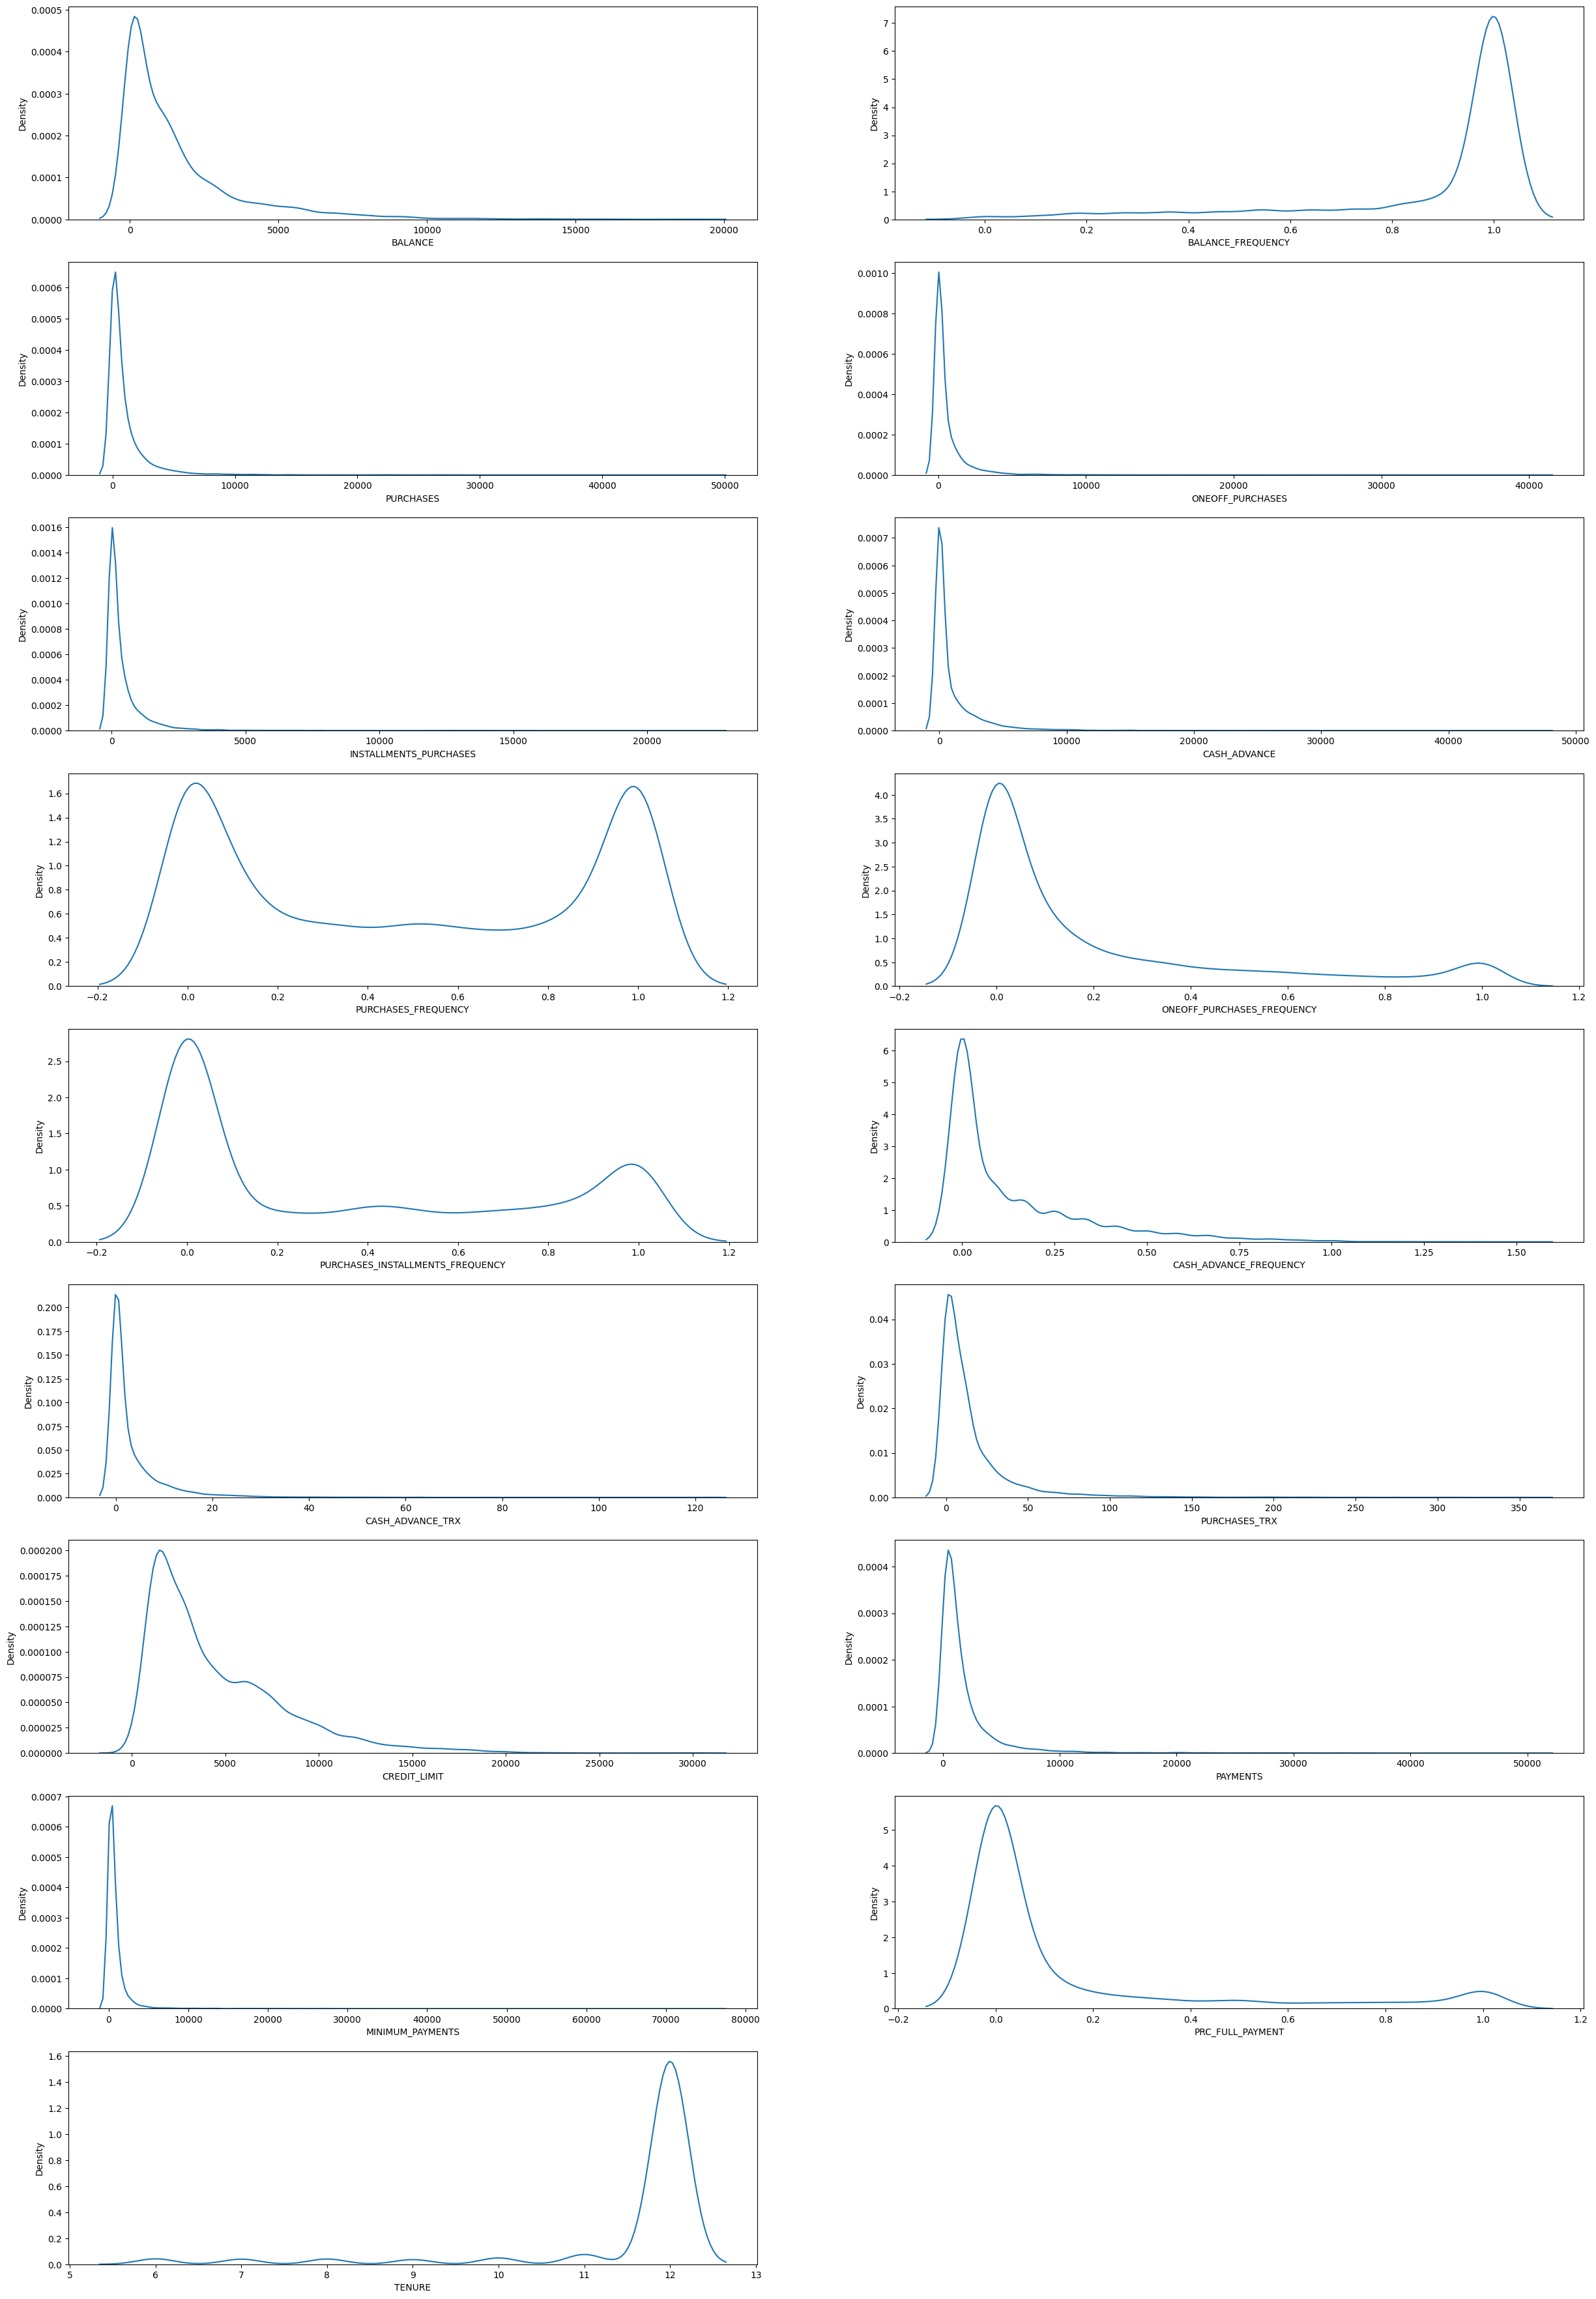

In [ ]:
plt.figure(figsize=(30,45))
for i, col in enumerate(df.columns):
     if df[col].dtype !='object':
      ax = plt.subplot(9, 2, i+1)
      sns.kdeplot(df[col], ax=ax)
      plt.xlabel(col)

plt.show

<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

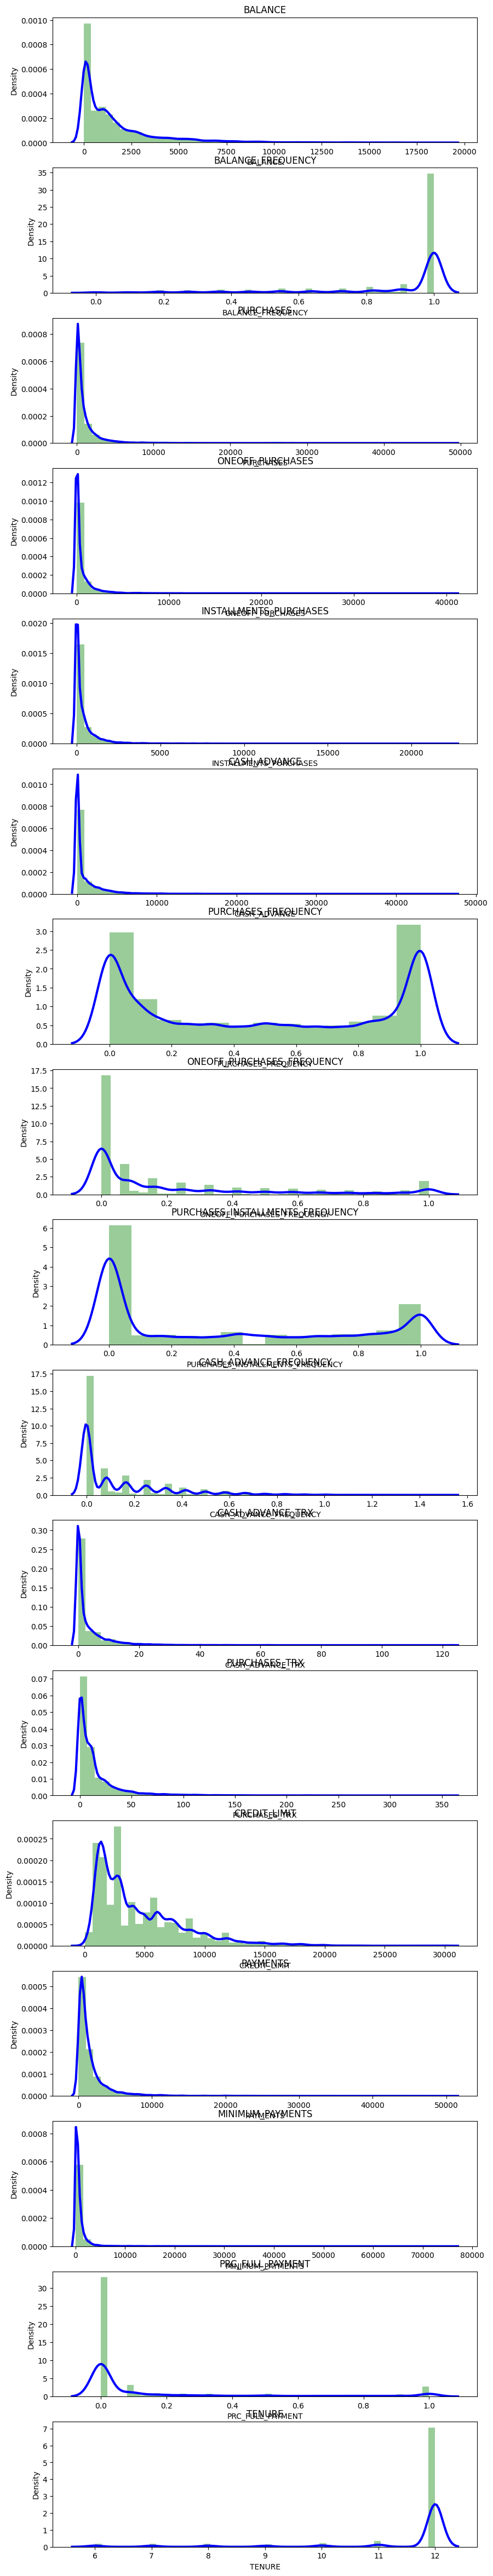

In [ ]:
plt.figure(figsize=(10,60))
for i in range(0,17):
  plt.subplot(17,1,i+1)
  sns.distplot(df[df.columns[i]],kde_kws={'color' : 'b', 'bw' : 0.1,'lw' : 3, 'label': 'KDE'},hist_kws={'color':'g'})
  plt.title(df.columns[i])

plt.tight_layout

<function matplotlib.pyplot.show(close=None, block=None)>

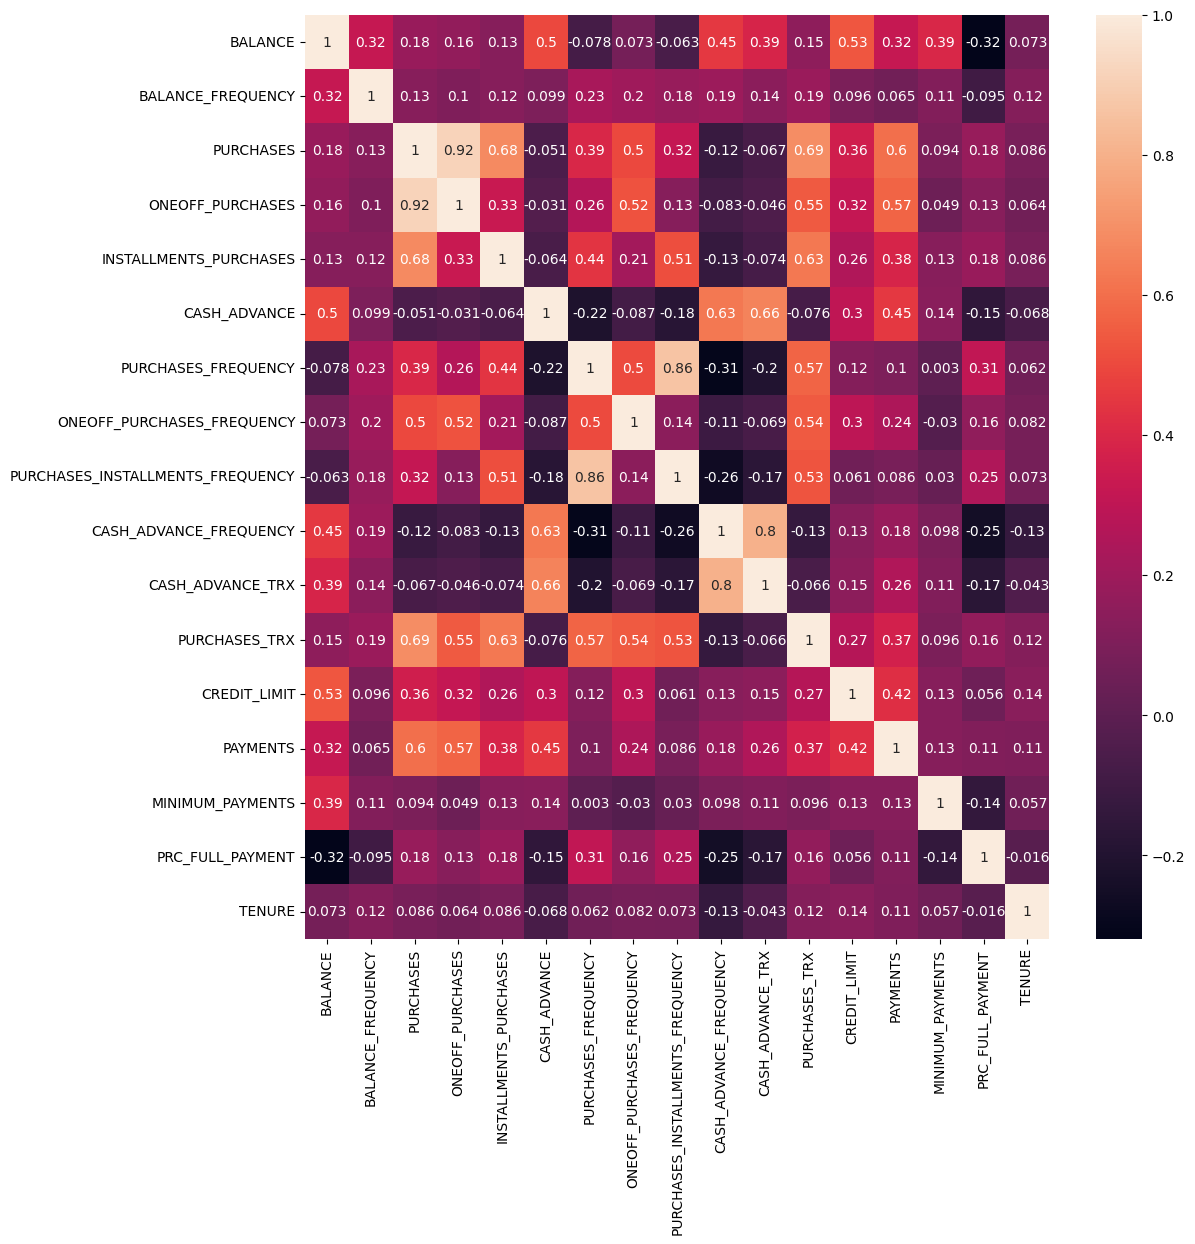

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(),annot=True)
plt.show

## Scaling the Dataframe

In [ ]:
scaled_df = scalar.fit_transform(df)

## Dimensionality reduction

**Converting the Dataframe into 2D Dataframe for Visualization**

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(data=principal_components, columns=["PCA1", "PCA2"])
pca_df

,PCA1,PCA2
0,-1.682221,-1.076451
1,-1.138292,2.506488
2,0.969674,-0.383543
3,-0.873627,0.043171
4,-1.599435,-0.688584
...,...,...
8945,-0.359629,-2.016146
8946,-0.564366,-1.639118
8947,-0.926203,-1.810785
8948,-2.336550,-0.657964


## Hyperparameter tuning

**Finding K value with Elbow Method**

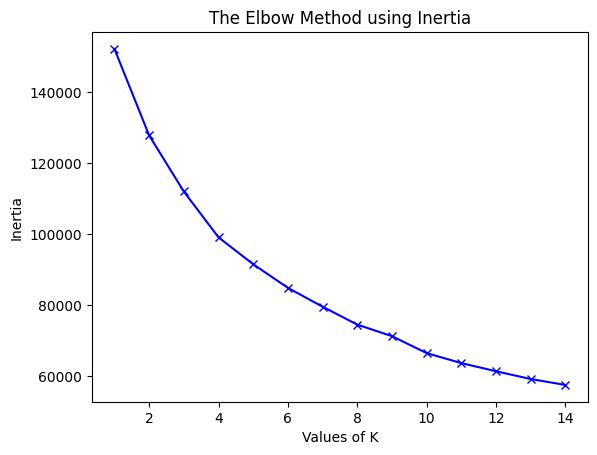

In [ ]:
inertia = []
range_val = range(1,15)
for i in range_val:
  kmean = KMeans(n_clusters=i)
  kmean.fit_predict(pd.DataFrame(scaled_df))
  inertia.append(kmean.inertia_)
plt.plot(range_val, inertia, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()


## Model building using KMeans

In [ ]:
kmeans_model=KMeans(4)
kmeans_model.fit_predict(scaled_df)
pca_df_kmeans= pd.concat([pca_df, pd.DataFrame({'cluster':kmeans_model.labels_})],axis=1)

## Visualizating the clustered Dataframe

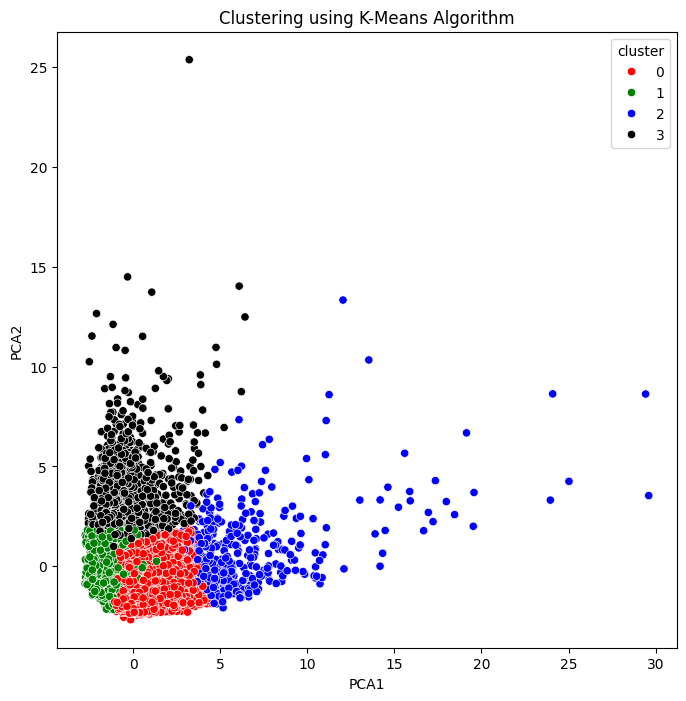

In [ ]:
if 'PCA1' in pca_df_kmeans.columns and 'cluster' in pca_df_kmeans.columns:
    plt.figure(figsize=(8, 8))
    ax = sns.scatterplot(x="PCA1", y="PCA2", hue="cluster", data=pca_df_kmeans, palette=['red', 'green', 'blue', 'black'])
    plt.title("Clustering using K-Means Algorithm")
    plt.show()
else:
    print("The required columns ('PCA1', 'cluster') are not present in the dataframe.")

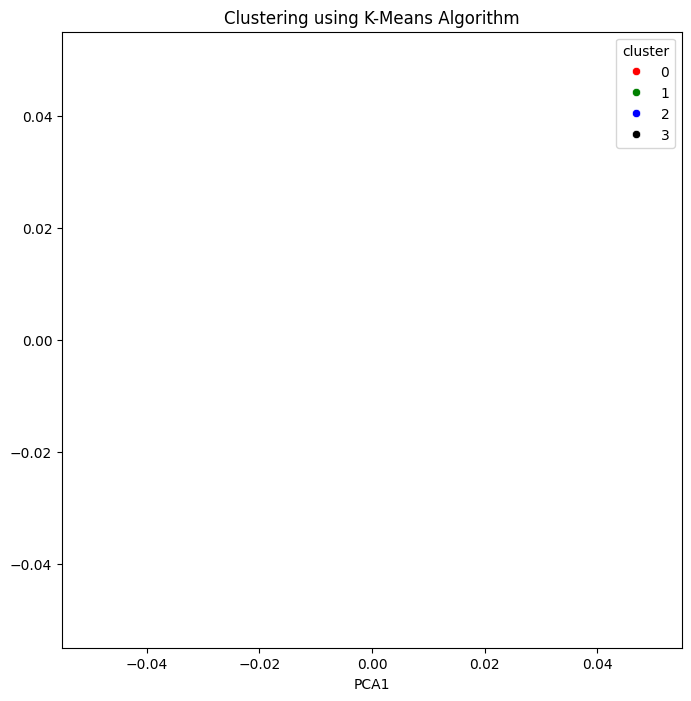

In [ ]:
plt.figure(figsize=(8,8))
ax=sns.scatterplot(x="PCA1",hue="cluster",data=pca_df_kmeans,palette=['red','green','blue','black'])
plt.title("Clustering using K-Means Algorithm")
plt.show()

In [ ]:
# Finding the centers of all clusters
cluster_centers = pd.DataFrame(data=kmeans_model.cluster_centers_,columns=[df.columns])
#inverse transform the data
cluster_centers = scalar.inverse_transform(cluster_centers)
cluster_centers = pd.DataFrame(data=cluster_centers,columns=[df.columns])
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,650.167072,0.269258,11.594595
1,1011.751528,0.789871,269.973466,209.853863,60.386625,595.759339,0.170146,0.086281,0.080578,0.114833,2.125503,2.903421,3277.703165,974.505090,586.301239,0.078001,11.446429
2,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1976.815179,0.286707,11.951100
3,4602.462714,0.968415,501.896219,320.373681,181.607404,4520.724309,0.287731,0.138934,0.185516,0.484526,14.284641,7.661102,7546.957050,3481.145990,2008.251157,0.034859,11.387312


In [ ]:
# Creating a target column "Cluster" for storing the cluster segment
cluster_df = pd.concat([df, pd.DataFrame({'Cluster': kmeans_model.labels_})], axis=1)
cluster_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,3
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,0
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6,0
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,1


<Axes: xlabel='Cluster', ylabel='count'>

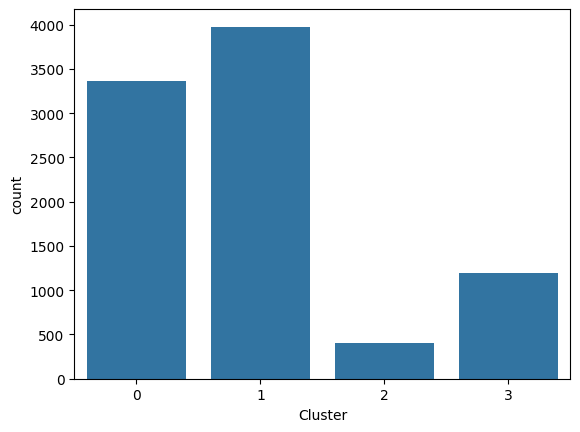

In [ ]:
# Visualization
sns.countplot(x='Cluster',data=cluster_df)

<function matplotlib.pyplot.show(close=None, block=None)>

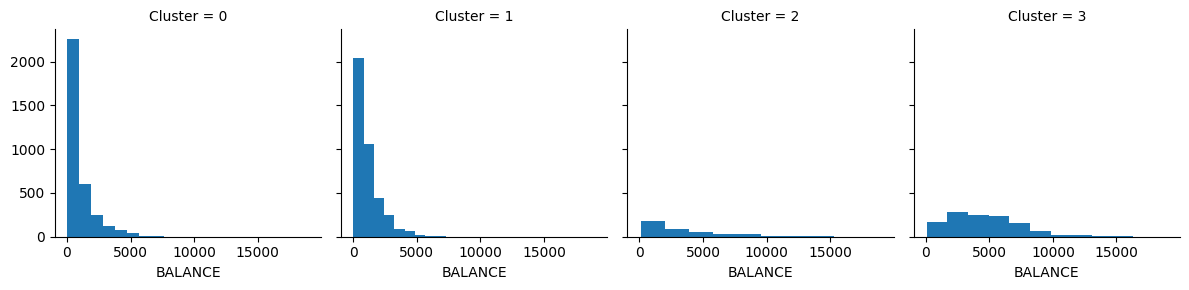

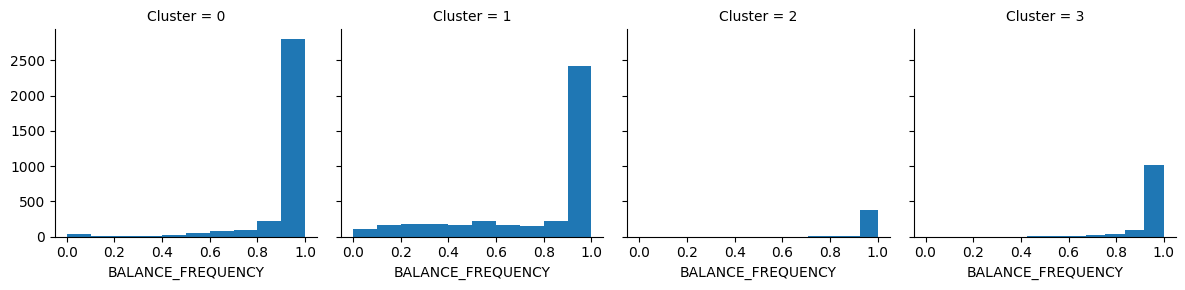

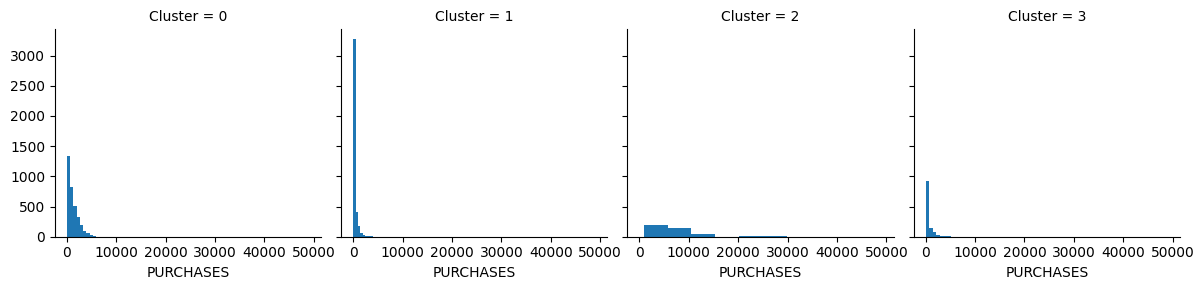

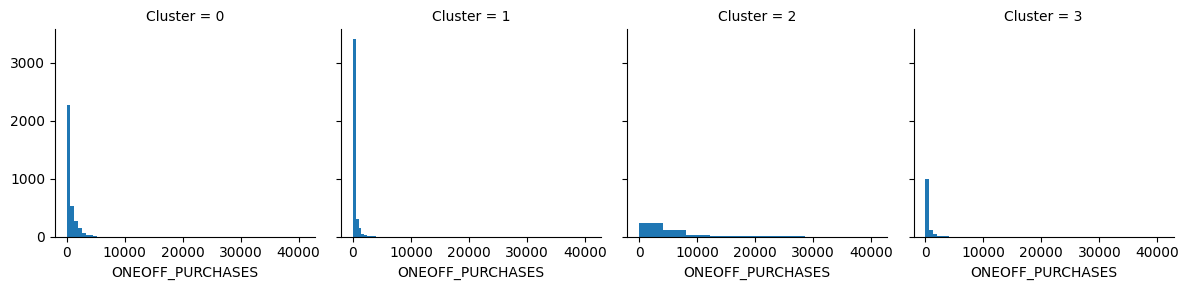

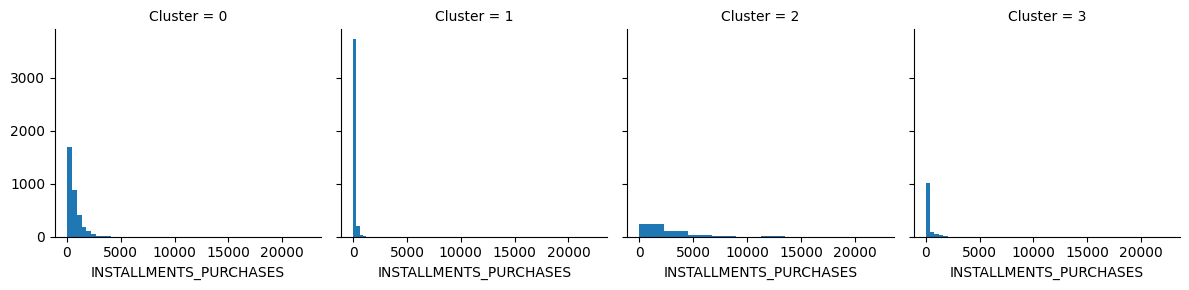

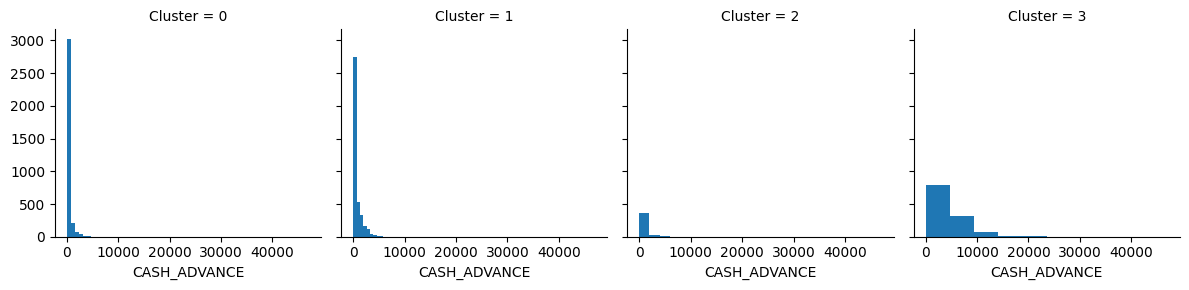

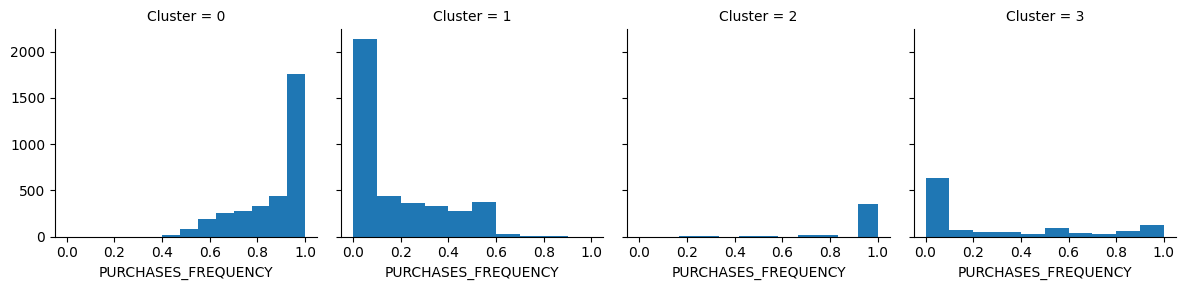

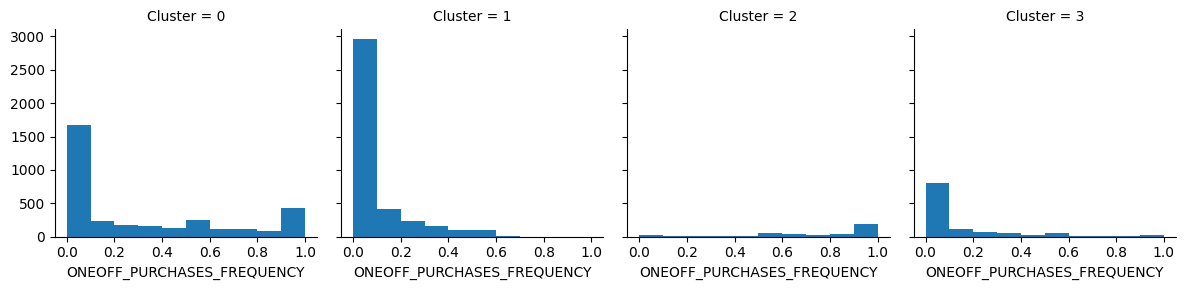

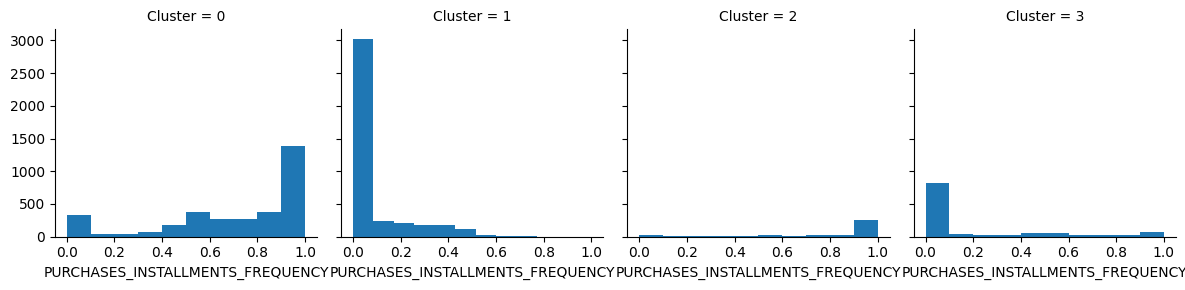

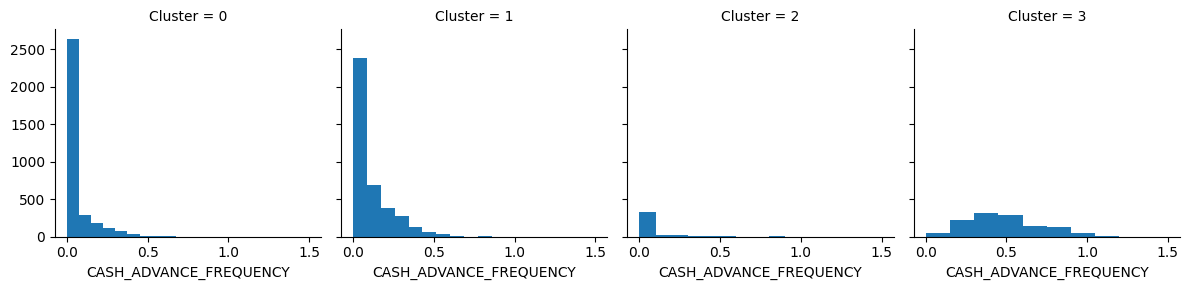

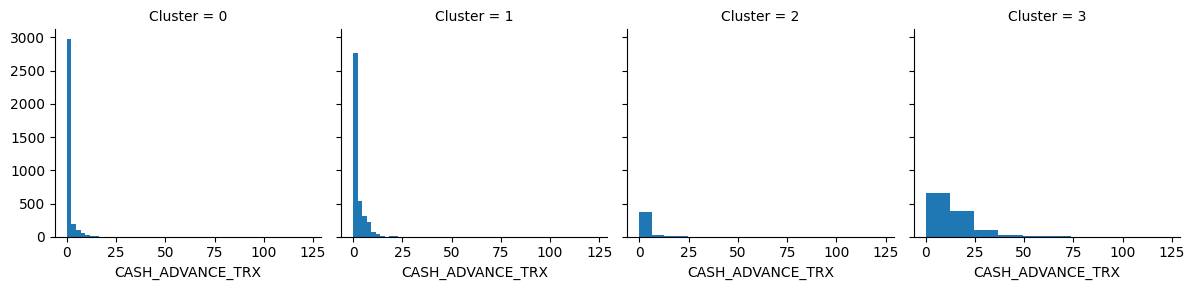

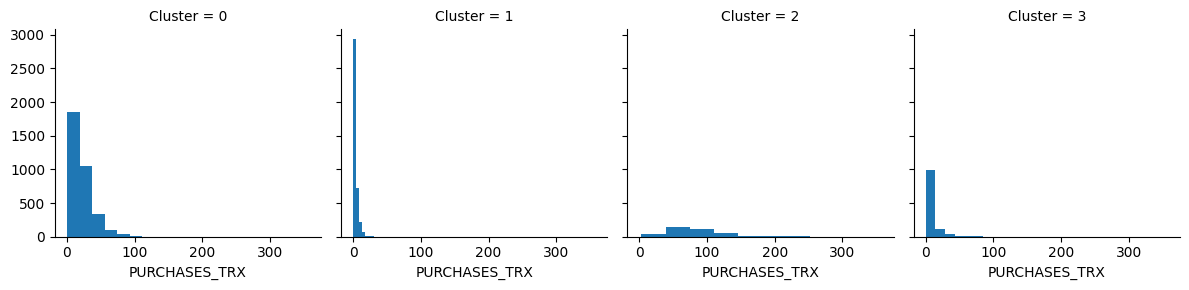

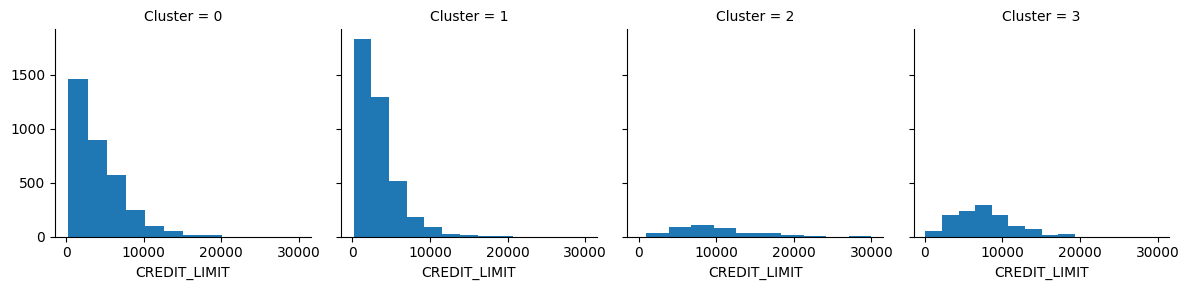

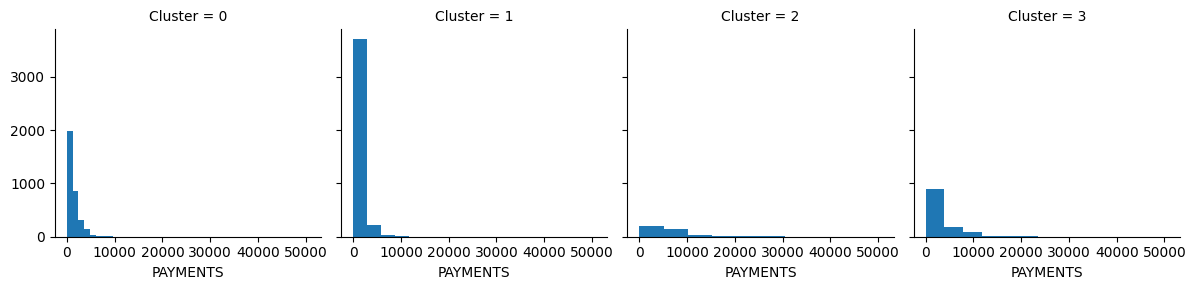

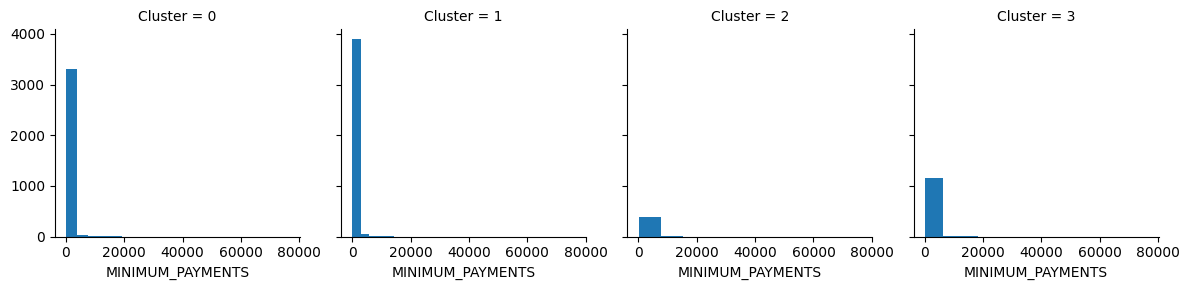

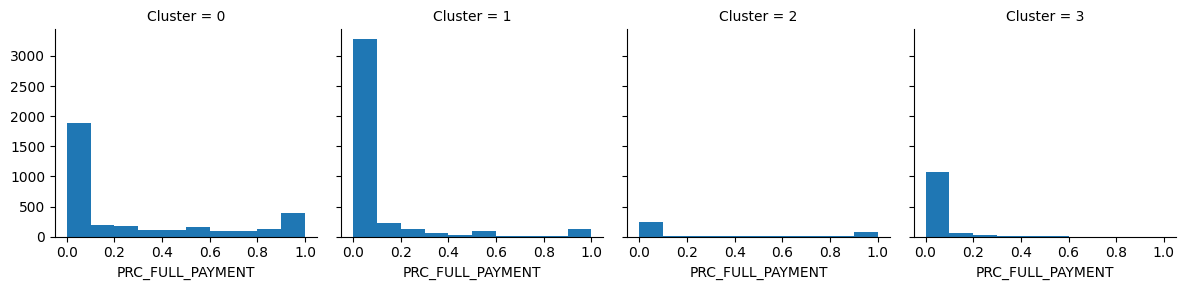

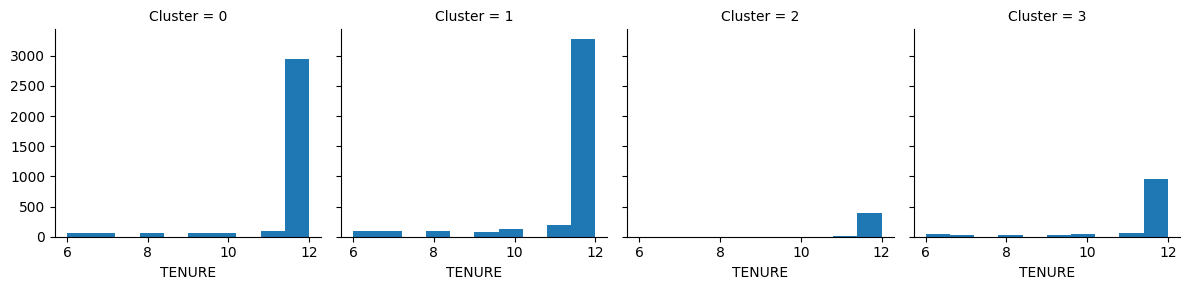

In [ ]:
for c in cluster_df.drop(['Cluster'],axis=1):
  grid= sns.FacetGrid(cluster_df, col='Cluster')
  grid= grid.map(plt.hist, c)

plt.show

## Saving the K-Means clustering model and the cluster label

In [ ]:
# Saving Scikitlearn models
import joblib
joblib.dump(kmeans_model, "kmeans_model.pk")

["kmeans_model.pk"]

['kmeans_model.pk']

In [ ]:
cluster_df.to_csv("Clustered_Customer_Data.csv")

## Training and Testing the model accuracy using decision tree

In [ ]:
#Split Dataset
X = cluster_df.drop(['Cluster'],axis=1)
y = cluster_df[['Cluster']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [ ]:
X_train

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
1645,1250.885289,1.000000,892.19,363.85,528.34,0.000000,0.416667,0.083333,0.416667,0.000000,0,6,1800.0,461.638318,296.027848,0.000000,12
1358,187.212600,1.000000,1807.08,967.08,840.00,0.000000,1.000000,0.416667,0.916667,0.000000,0,19,10000.0,1681.194004,175.755159,1.000000,12
8898,379.288635,0.714286,550.00,50.00,500.00,388.818230,0.571429,0.142857,0.571429,0.142857,2,6,500.0,509.404913,531.988210,0.000000,7
8309,6008.914524,0.777778,0.00,0.00,0.00,8304.470149,0.000000,0.000000,0.000000,0.333333,9,0,9000.0,1279.301117,1404.889491,0.000000,9
5929,319.696908,1.000000,3884.19,2265.90,1618.29,0.000000,1.000000,1.000000,0.833333,0.000000,0,43,9000.0,3682.437155,212.358132,0.416667,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4769,1540.879308,0.909091,0.00,0.00,0.00,154.550357,0.000000,0.000000,0.000000,0.090909,1,0,4000.0,720.558343,334.635642,0.000000,11
2572,989.022229,1.000000,0.00,0.00,0.00,559.200528,0.000000,0.000000,0.000000,0.416667,5,0,1200.0,1071.879544,263.735953,0.000000,12
7042,1004.526608,0.857143,0.00,0.00,0.00,1090.788584,0.000000,0.000000,0.000000,0.142857,5,0,1200.0,65.437308,1617.834987,0.000000,7
5326,1248.193121,1.000000,40.13,0.00,40.13,0.000000,0.083333,0.000000,0.083333,0.000000,0,1,1750.0,293.330975,343.940892,0.000000,12


In [ ]:
X_test

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
6154,4.596178,0.090909,554.16,0.00,554.16,0.000000,0.083333,0.000000,0.083333,0.000000,0,1,1500.0,0.000000,864.206542,0.000000,12
2079,8636.950854,1.000000,972.09,43.00,929.09,2590.575082,1.000000,0.083333,1.000000,0.416667,8,26,10500.0,2025.270282,2959.401317,0.000000,12
5426,293.118363,1.000000,368.91,0.00,368.91,683.536421,0.750000,0.000000,0.750000,0.166667,3,18,1800.0,1309.489418,195.953485,0.166667,12
2480,166.258538,0.909091,1377.31,827.35,549.96,133.878836,1.000000,0.083333,1.000000,0.083333,1,14,16000.0,1770.052426,190.754221,0.090909,12
5143,95.887902,1.000000,769.00,325.00,444.00,0.000000,0.666667,0.416667,0.250000,0.000000,0,15,4000.0,958.996228,151.156275,0.400000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,1089.475719,1.000000,0.00,0.00,0.00,287.364895,0.000000,0.000000,0.000000,0.083333,1,0,3000.0,373.306733,231.573591,0.000000,12
4163,2165.436389,1.000000,0.00,0.00,0.00,1016.336335,0.000000,0.000000,0.000000,0.250000,6,0,2500.0,435.641940,745.905341,0.000000,12
5101,4020.130769,1.000000,79.62,79.62,0.00,5457.123658,0.083333,0.083333,0.000000,0.250000,23,1,9500.0,7058.832194,1040.283795,0.100000,12
94,2329.485768,1.000000,213.34,213.34,0.00,0.000000,0.250000,0.250000,0.000000,0.000000,0,3,2400.0,0.000000,864.206542,0.000000,12


In [ ]:
#Decision_Tree
model= DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
#Confusion_Matrix
print(metrics.confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 911   19   13   13]
 [  33 1174    0   32]
 [  11    0  115    3]
 [  22   22    3  314]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       956
           1       0.97      0.95      0.96      1239
           2       0.88      0.89      0.88       129
           3       0.87      0.87      0.87       361

    accuracy                           0.94      2685
   macro avg       0.91      0.92      0.91      2685
weighted avg       0.94      0.94      0.94      2685



## Saving the Decision Tree model for future predictions

In [ ]:
import pickle
filename = 'final_model.sav'
pickle.dump(model, open(filename, 'wb'))

# sometime later

#load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
result= loaded_model.score(X_test, y_test)
print(result, '% Accuracy')

0.9363128491620112 % Accuracy
